In [1]:
! pip install pandas matplotlib numpy tensorflow scikit-learn
! pip install nvidia-cudnn-cu12==9.3.0.75

DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
DEPRECATION: Loading egg at /root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/paddleseg-0.0.0.dev0-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Input,
    Add,
    LayerNormalization
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from utils.boxe_utils import *
from utils.stance_utils import *

I0000 00:00:1782528545.823597   91175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782528545.912341   91175 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782528548.696391   91175 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [3]:
TRAIN_VIDEOS = ["V1", "V2", "V7", "V8", "V3", "V4"]
TEST_VIDEOS  = ["V5", "V9", "V10"]

def load_concat(vids):
    Xs = []
    ys = []

    for v in vids:
        sk, lb = load_video(v)
        Xs.append(sk.astype(np.float32))
        ys.append(lb)

    return np.concatenate(Xs), np.concatenate(ys)

X_tr_all, y_tr_all = load_concat(TRAIN_VIDEOS)
X_te, y_te_raw = load_concat(TEST_VIDEOS)

print(f"X_tr_all shape: {X_tr_all.shape}")
print(f"y_tr_all shape: {y_tr_all.shape}")
print(f"X_te shape: {X_te.shape}")
print(f"y_te_raw shape: {y_te_raw.shape}")

X_tr_all shape: (3867, 25, 17, 2)
y_tr_all shape: (3867,)
X_te shape: (899, 25, 17, 2)
y_te_raw shape: (899,)


In [4]:
def convert_label(label):
    mapping = {
        'Jab': 'Straight', 'Cross': 'Straight',
        'Lead Hook': 'Hook', 'Rear Hook': 'Hook',
        'Lead Uppercut': 'Uppercut', 'Rear Uppercut': 'Uppercut',
    }
    return mapping[label]
    
y_tr_all = np.array([convert_label(y) for y in y_tr_all])
y_te_raw = np.array([convert_label(y) for y in y_te_raw])

classes, label_to_id, id_to_label = build_label_mapping(y_tr_all)

y_tr_all_id = np.array([label_to_id[x] for x in y_tr_all])
y_te = np.array([label_to_id[x] for x in y_te_raw])

num_classes = len(classes)

print(f"Classes: {classes}")
print(f"label_to_id: {label_to_id}")
print(f"num_classes: {num_classes}")
print(f"\ny_tr_all_id unique values: {np.unique(y_tr_all_id)}")
print(f"y_tr_all_id distribution:")
unique, counts = np.unique(y_tr_all_id, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

Classes: ['Hook', 'Straight', 'Uppercut']
label_to_id: {'Hook': 0, 'Straight': 1, 'Uppercut': 2}
num_classes: 3

y_tr_all_id unique values: [0 1 2]
y_tr_all_id distribution:
  Hook: 1035
  Straight: 2139
  Uppercut: 693


In [5]:
tr_idx, val_idx = train_test_split(
    np.arange(len(y_tr_all_id)),
    test_size=0.35,
    stratify=y_tr_all_id,
    random_state=42
)

X_tr = X_tr_all[tr_idx]
y_tr = y_tr_all_id[tr_idx]

X_val = X_tr_all[val_idx]
y_val = y_tr_all_id[val_idx]

print(f"X_tr shape: {X_tr.shape}, y_tr shape: {y_tr.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"\nTrain distribution:")

unique, counts = np.unique(y_tr, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")
print(f"\nVal distribution:")

unique, counts = np.unique(y_val, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {id_to_label[u]}: {c}")

X_tr shape: (2513, 25, 17, 2), y_tr shape: (2513,)
X_val shape: (1354, 25, 17, 2), y_val shape: (1354,)

Train distribution:
  Hook: 673
  Straight: 1390
  Uppercut: 450

Val distribution:
  Hook: 362
  Straight: 749
  Uppercut: 243


In [6]:
def axis_stats(X):
    B = body_frame_windows(X)
    x = B[...,0]
    y = B[...,1]
    mean = np.array([
        x[x != 0].mean(),
        y[y != 0].mean()
    ])
    std = np.array([
        x[x != 0].std() + 1e-6,
        y[y != 0].std() + 1e-6
    ])
    return mean.astype(np.float32), std.astype(np.float32)

def std_va(B):
    X = B.reshape(len(B), WINDOW_LEN, 34).copy()
    X[:,:,0::2] = (X[:,:,0::2] - mean[0]) / std[0]
    X[:,:,1::2] = (X[:,:,1::2] - mean[1]) / std[1]
    return add_velocity_and_acceleration(X)

def feats(X):
    return std_va(body_frame_windows(X))

In [7]:
mean, std = axis_stats(X_tr)

np.savez("norm_stats.npz", mean=mean, std=std)

def flip_body(B):
    SWAP_J = [(1,2), (3,4), (5,6), (7,8), (9,10), (11,12), (13,14), (15,16)]
    F = B.copy()
    F[...,0] *= -1
    for a,b in SWAP_J:
        tmp = F[:,:,a,:].copy()
        F[:,:,a,:] = F[:,:,b,:]
        F[:,:,b,:] = tmp
    return F

B_tr = body_frame_windows(X_tr)
X_tr_feat = np.concatenate([std_va(B_tr), std_va(flip_body(B_tr))])
y_tr_final = np.concatenate([y_tr, y_tr])

print(f"X_tr_feat shape: {X_tr_feat.shape} (original + mirrored)")
print(f"y_tr_final shape: {y_tr_final.shape}")
print(f"\ny_tr_final distribution:")

unique, counts = np.unique(y_tr_final, return_counts=True)
for u, c in zip(unique, counts):
    pct = 100 * c / len(y_tr_final)
    print(f"  {id_to_label[u]}: {c} ({pct:.1f}%)")

X_tr_feat shape: (5026, 25, 102) (original + mirrored)
y_tr_final shape: (5026,)

y_tr_final distribution:
  Hook: 1346 (26.8%)
  Straight: 2780 (55.3%)
  Uppercut: 900 (17.9%)


In [8]:
def build_model(input_shape, nc):

    inp = Input(shape=input_shape)
    x = Bidirectional(
        LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2)
    )(inp)

    x = Dropout(0.3)(x)

    att = MultiHeadAttention(num_heads=2, key_dim=32)(x,x)
    x = Add()([x,att])
    x = LayerNormalization()(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu", kernel_regularizer=l2(5e-4))(x)
    x = Dropout(0.3)(x)

    out = Dense(nc, activation="softmax")(x)

    return Model(inp,out)

model = build_model(input_shape=X_tr_feat.shape[1:], nc=num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1782528559.166869   91175 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 34959 MB memory:  -> device: 0, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:1b:00.0, compute capability: 9.0a
I0000 00:00:1782528559.177322   91175 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 62115 MB memory:  -> device: 1, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:43:00.0, compute capability: 9.0a
I0000 00:00:1782528559.186783   91175 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 57879 MB memory:  -> device: 2, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:52:00.0, compute capability: 9.0a
I0000 00:00:1782528559.195602   91175 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 62037 MB memory:  -> device: 3, name: NVIDIA H100 80GB HBM3, pci bus id: 0000:61:00.0, compute capability: 9.0a
I0000 00:00:1782528559.206532   91175 gpu_device.cc:2043] Cr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 25, 102)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 25, 128)   │     85,504 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 25, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 25, 128)   │     33,088 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 25, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 25, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 127,299 (497.26 KB)

 Trainable params: 127,299 (497.26 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
weights = compute_class_weight(
    "balanced",
    classes=np.unique(y_tr_final),
    y=y_tr_final
)

class_weights = dict(enumerate(weights))

class_weights[label_to_id["Hook"]] *= 2.5
class_weights[label_to_id["Uppercut"]] *= 2.5

print(class_weights)

{0: 3.1116889549281823, 1: 0.6026378896882494, 2: 4.6537037037037035}


In [10]:
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max"
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        mode="min"
    ),
    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    )
]

In [11]:
y_tr_oh = tf.keras.utils.to_categorical(
    y_tr_final,
    num_classes
)

y_val_oh = tf.keras.utils.to_categorical(
    y_val,
    num_classes
)


start_time = datetime.now()
model.fit(
    X_tr_feat,
    y_tr_oh,
    validation_data=(feats(X_val), y_val_oh),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks
)
end_time = datetime.now()

total_time = end_time - start_time
minutes = total_time.total_seconds() / 60
print("Tempo total de treinamento (min):", round(minutes, 2))

Epoch 1/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 57s 269ms/step - accuracy: 0.2809 - loss: 2.0910 - val_accuracy: 0.2792 - val_loss: 1.4372 - learning_rate: 5.0000e-04
Epoch 2/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 251ms/step - accuracy: 0.3211 - loss: 1.9537 - val_accuracy: 0.3900 - val_loss: 1.2142 - learning_rate: 5.0000e-04
Epoch 3/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.4113 - loss: 1.8792 - val_accuracy: 0.4350 - val_loss: 1.4219 - learning_rate: 5.0000e-04
Epoch 4/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 41s 255ms/step - accuracy: 0.4650 - loss: 1.7688 - val_accuracy: 0.5679 - val_loss: 1.0275 - learning_rate: 5.0000e-04
Epoch 5/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step - accuracy: 0.5330 - loss: 1.6839 - val_accuracy: 0.6640 - val_loss: 0.8499 - learning_rate: 5.0000e-04
Epoch 6/100
158/158 ━━━━━━━━━━━━━━━━━━━━ 40s 253ms/step - accuracy: 0.5597 - loss: 1.6110 - val_accuracy: 0.6108 - val_loss: 0.9865 - learning_rate: 5.0000e-04
Epoch 7/100
158/158 ━━━━━━━━━━━━━━━━━━━━

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step
              precision    recall  f1-score   support

        Hook       0.68      0.69      0.68       172
    Straight       0.91      0.91      0.91       519
    Uppercut       0.76      0.76      0.76       208

    accuracy                           0.83       899
   macro avg       0.78      0.78      0.78       899
weighted avg       0.83      0.83      0.83       899



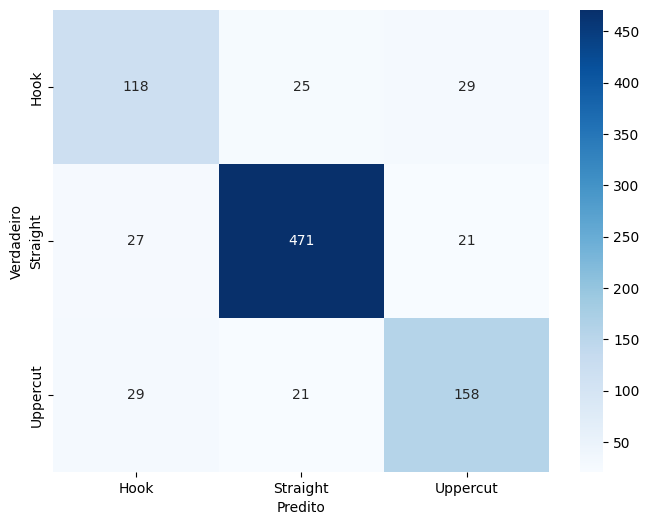

In [12]:
best_model = load_model("best_model.keras")
X_te_feat = feats(X_te) 
y_pred = np.argmax(best_model.predict(X_te_feat), axis=1)

print(classification_report(y_te, y_pred, target_names=classes))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.savefig("matrix.pdf", bbox_inches='tight')
plt.show()

In [13]:
best_model.save("modelo_boxe.keras")